In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import random
import os
import json
import re
from pathlib import Path
import pandas as pd
from itertools import product

# Set device (use GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

C:\Users\LiamUser\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


# Part 1: Load/Analyze Data

##What is your dataset? Please describe your dataset and where you got it

My dataset is a collection of text messages over discord that me and my friend group have sent to each other, since about 2018. Discord allows for users to request their own message data, which provides all of that user's messages in a json file per text channel. I requested my own data, and asked my friends if they were willing to request and send their own data to me to train a small LLM on for a class, and for further expansion into maybe a bot or something for us to laugh at.

##Load your dataset / Implement your dataloader

In [2]:
# load your dataset and set up your dataloader
# If applicable, please include your data with your final submission
# along with instructions for how to load it
raw = Path("./data/raw")
processed = Path("./data/processed")
processed.mkdir(parents=True, exist_ok=True)

user_exports = {
    "liam": raw / "liam-messages",
    "jade": raw / "jade-messages",
    "dylan": raw / "dylan-messages",
    "olive": raw / "olive-messages",
    "gabe": raw / "gabe-messages",
}

discord_names = {
    "liam": "fruitattack",
    "jade": "devilz",
    "dylan": "gandalf_4212",
    "olive": "himynamerobo",
    "gabe": "valr0k77",
}

name_normalization = [
    (re.compile(r"\bAaron\b", flags=re.IGNORECASE), "olive"),
    (re.compile(r"\bErin\b", flags=re.IGNORECASE), "olive"),
    (re.compile(r"\bJeff\b", flags=re.IGNORECASE), "jade"),
]

# Here's all the raw data cleaning/preprocessing stuff below
# Use only user data that I actually have right now, since some of my friends data might not arrive in time for the assignment
user_exports = {k: v for k, v in user_exports.items() if v.exists()}
print("Found raw data for:", list(user_exports.keys()))

whitespace = re.compile(r"\s+")

def clean_text(text):
    if text is None:
        return ""

    text = str(text)

    for pattern, replacement in name_normalization:
        text = pattern.sub(replacement, text)

    text = whitespace.sub(" ", text).strip()
    return text

def normalize_channel_id(folder_name):
    match = re.search(r"(\d+)", folder_name)
    return match.group(1) if match else folder_name
    
punct = re.compile(r"[^\w\s]+")

def spam_signature(text):
    if not text:
        return ""

    text = text.lower().strip()
    text = punct.sub(" ", text)
    text = whitespace.sub(" ", text).strip()

    if text == "":
        return ""

    tokens = text.split()

    # Collapse consecutive repeated words inside one message
    collapsed = []
    for token in tokens:
        if not collapsed or token != collapsed[-1]:
            collapsed.append(token)

    return " ".join(collapsed)


def cap_consecutive_spam(df, max_repeats=5):
    df = df.sort_values(["author_name", "channel_id", "timestamp", "message_id"]).copy()
    df["spam_sig"] = df["text_clean"].apply(spam_signature)

    keep_mask = np.ones(len(df), dtype=bool)

    for (_, _), group in df.groupby(["author_name", "channel_id"], sort=False):
        prev_sig = None
        run_len = 0

        idxs = group.index.tolist()
        for idx in idxs:
            sig = df.at[idx, "spam_sig"]

            if sig == prev_sig:
                run_len += 1
            else:
                prev_sig = sig
                run_len = 1

            if run_len > max_repeats:
                keep_mask[df.index.get_loc(idx)] = False

    out = df.loc[keep_mask].copy()
    return out


def load_one_export(person_name, export_dir):
    index_path = export_dir / "index.json"
    if not index_path.exists():
        raise FileNotFoundError(f"Missing {index_path}")

    with open(index_path, "r", encoding="utf-8") as f:
        index_map = json.load(f)

    rows = []

    for child in export_dir.iterdir():
        if not child.is_dir():
            continue

        folder_channel_id = normalize_channel_id(child.name)
        channel_json_path = child / "channel.json"
        messages_json_path = child / "messages.json"

        if not messages_json_path.exists():
            continue

        channel_meta = {}
        if channel_json_path.exists():
            with open(channel_json_path, "r", encoding="utf-8") as f:
                channel_meta = json.load(f)

        with open(messages_json_path, "r", encoding="utf-8") as f:
            messages = json.load(f)

        channel_id = str(channel_meta.get("id", folder_channel_id))
        channel_name = index_map.get(channel_id, "UNKNOWN_CHANNEL")
        channel_type = channel_meta.get("type", "UNKNOWN")
        recipients = channel_meta.get("recipients", [])

        for m in messages:
            text_raw = m.get("Contents", "") or ""
            attachments = m.get("Attachments", "") or ""

            rows.append({
                "message_id": int(m["ID"]),
                "timestamp": pd.to_datetime(m["Timestamp"]),
                "author_name": person_name,
                "author_username": discord_names.get(person_name, person_name),
                "channel_id": channel_id,
                "channel_name": channel_name,
                "channel_type": channel_type,
                "recipients": json.dumps(recipients),
                "text_raw": text_raw,
                "text_clean": clean_text(text_raw),
                "attachments": attachments,
                "has_attachments": attachments != "",
                "source_export": export_dir.name,
            })

    df = pd.DataFrame(rows)

    df = df.drop_duplicates(subset=["message_id"]).copy()

    return df

# Load parquet files if they already exist, otherwise we'll look for the raw data to clean up and save.
all_path = processed / "all_messages.parquet"
model_path = processed / "model_messages.parquet"
train_path = processed / "train.parquet"
val_path = processed / "val.parquet"
test_path = processed / "test.parquet"

have_data = all(p.exists() for p in [all_path, model_path, train_path, val_path, test_path])

if have_data:

    all_messages = pd.read_parquet(all_path)
    model_messages = pd.read_parquet(model_path)
    train_df = pd.read_parquet(train_path)
    val_df = pd.read_parquet(val_path)
    test_df = pd.read_parquet(test_path)
    print("Loaded parquet file")

    # just to be safe
    for df in [all_messages, model_messages, train_df, val_df, test_df]:
        df["timestamp"] = pd.to_datetime(df["timestamp"])

else:
    print("Processing data...")

    dfs = []
    for person_name, export_dir in user_exports.items():
        df_person = load_one_export(person_name, export_dir)
        print(person_name, len(df_person))
        dfs.append(df_person)

    all_messages = pd.concat(dfs, ignore_index=True)
    all_messages = all_messages.sort_values("timestamp").reset_index(drop=True)

    print("Total messages loaded:", len(all_messages))

    # I only want to load messages where at least 2 of us are in that channel
    participants_per_channel = (all_messages.groupby("channel_id")["author_name"].nunique().sort_values(ascending=False))
    eligible_channels = participants_per_channel[participants_per_channel >= 2].index

    model_messages = all_messages[all_messages["channel_id"].isin(eligible_channels)].copy()
    model_messages = model_messages.sort_values("timestamp").reset_index(drop=True)

    before_spam_cap = len(model_messages)
    model_messages = cap_consecutive_spam(model_messages, max_repeats=5)
    model_messages = model_messages.sort_values("timestamp").reset_index(drop=True)

    model_messages = model_messages[model_messages["text_clean"] != ""].copy()
    model_messages = model_messages.reset_index(drop=True)

    print("Kept messages before spam removal:", before_spam_cap)
    print("Kept messages after spam removal: ", len(model_messages))

    # train/val/test split
    n = len(model_messages)
    train_end = int(0.8 * n)
    val_end = int(0.9 * n)

    train_df = model_messages.iloc[:train_end].copy()
    val_df   = model_messages.iloc[train_end:val_end].copy()
    test_df  = model_messages.iloc[val_end:].copy()

    print("Train:", len(train_df))
    print("Val:  ", len(val_df))
    print("Test: ", len(test_df))

    all_messages.to_parquet(all_path, index=False)
    model_messages.to_parquet(model_path, index=False)
    train_df.to_parquet(train_path, index=False)
    val_df.to_parquet(val_path, index=False)
    test_df.to_parquet(test_path, index=False)

    print("Saved processed files to:", processed)

# Dataloader and vocab stuff
def end_channels_and_messages(df):
    pieces = []

    for channel_id, group in df.groupby("channel_id"):
        group = group.sort_values("timestamp")
        msgs = [msg for msg in group["text_clean"].tolist() if msg]

        if len(msgs) == 0:
            continue

        channel_text = "\n<EOS>\n".join(msgs)
        pieces.append(channel_text)

    return "\n<CHANNEL_BREAK>\n".join(pieces)

train_text = end_channels_and_messages(train_df)
val_text = end_channels_and_messages(val_df)
test_text = end_channels_and_messages(test_df)

special_tokens= ["<PAD>", "<UNK>"]
train_chars = sorted(set(train_text))
itos = special_tokens + train_chars
stoi = {ch: i for i, ch in enumerate(itos)}

PAD_I = stoi["<PAD>"]
UNK_I = stoi["<UNK>"]
VOCAB_SIZE = len(itos)

def encode(text):
    return [stoi.get(ch, UNK_I) for ch in text]

def decode(ids):
    return "".join(itos[i] for i in ids if i >= 2)

class MessageDataset(Dataset):
    def __init__(self, text, seq_len=128):
        self.seq_len = seq_len
        self.data = torch.tensor(encode(text), dtype=torch.long)

    def __len__(self):
        return max(0, len(self.data) - self.seq_len)

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y

seq_len = 128
batch_size = 64

train_dataset = MessageDataset(train_text, seq_len=seq_len)
val_dataset = MessageDataset(val_text, seq_len=seq_len)
test_dataset = MessageDataset(test_text, seq_len=seq_len)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print("Train batchs:", len(train_loader))
print("Validation batchs:  ", len(val_loader))
print("Test batchs: ", len(test_loader))

Found raw data for: []
Loaded parquet file
Train batchs: 49264
Validation batchs:   6072
Test batchs:  8815


##Dataset Analyis Statistics

Unique channels: 45
Unique authors: 4
Average chars/message: 26.908772156255377
Average words/message: 4.670925830321804 

Example 1
Message: Then done!!!


Example 2
Message: Oh it did?


Example 3
Message: Because then I can play as two characters at once :3


Example 4
Message: I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR I HATE STEAM VR


Example 5
Message: Different breed right here


Example 6
Message: F


Example 7
Message: Click the little forgot password thing


Example 8
Message: work was busy all day today, and then died right when I got off work


Example 9
Message: dude I hate when that happens


Example 10
Message: we're doing max right liam


Unique words: 44267
Top 20 words: [('i', 19315), ('the', 12567), ('a', 11286), ('to', 10463), ('you', 9026), ('and', 7678), ('it', 7507), ('is', 5776), ('of', 5314), ('that', 5177), ('my', 5137), ('lol', 4824), ('in', 4777), ('so', 4598), ('like', 452

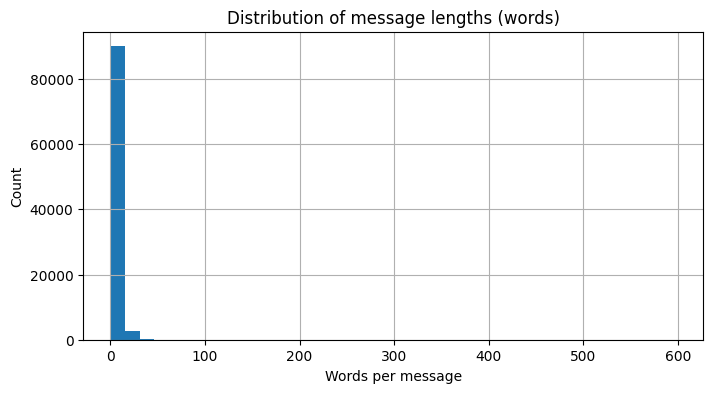

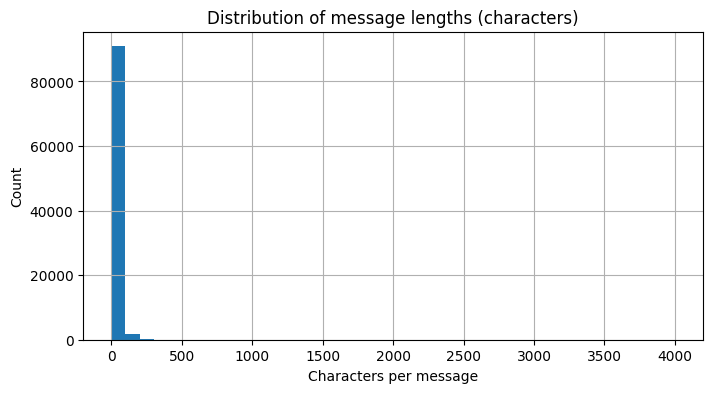

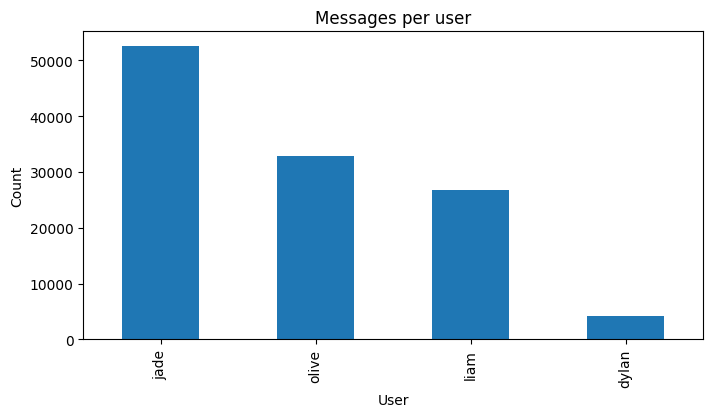

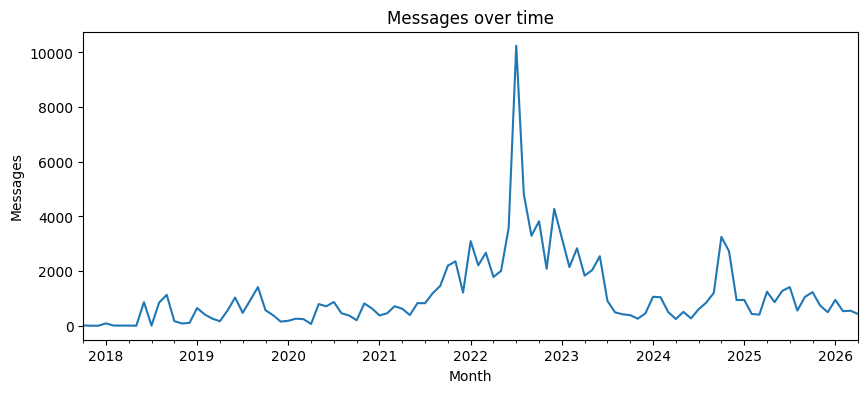

In [3]:
# code for collecting statistics from your dataset / plots and analysis
def add_stats(df):
    df = df.copy()
    df["char_len"] = df["text_clean"].str.len()
    df["word_len"] = df["text_clean"].str.split().str.len()
    return df

train_stats = add_stats(train_df)
val_stats = add_stats(val_df)
test_stats = add_stats(test_df)

print("Unique channels:", model_messages["channel_id"].nunique())
print("Unique authors:", model_messages["author_name"].nunique())

print("Average chars/message:", train_stats["char_len"].mean())
print("Average words/message:", train_stats["word_len"].mean(),"\n")

samples = train_df.sample(10)

for i, row in enumerate(samples.itertuples(), 1):
    print(f"Example {i}")
    print(f"Message: {row.text_clean}")
    print("\n")

all_words = []
for text in model_messages["text_clean"]:
    all_words.extend(text.lower().split())

word_counts = Counter(all_words)
print("Unique words:", len(word_counts))
print("Top 20 words:", word_counts.most_common(20))

display_cols = ["timestamp", "author_name", "channel_name", "text_clean"]
model_messages.sample(5)[display_cols]

plt.figure(figsize=(8, 4))
train_stats["word_len"].hist(bins=40)
plt.title("Distribution of message lengths (words)")
plt.xlabel("Words per message")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
train_stats["char_len"].hist(bins=40)
plt.title("Distribution of message lengths (characters)")
plt.xlabel("Characters per message")
plt.ylabel("Count")
plt.show()

msg_per_user = model_messages["author_name"].value_counts()
plt.figure(figsize=(8, 4))
msg_per_user.plot(kind="bar")
plt.title("Messages per user")
plt.xlabel("User")
plt.ylabel("Count")
plt.show()

messages_over_time = (
    model_messages
    .set_index("timestamp")
    .resample("ME")
    .size()
)

plt.figure(figsize=(10, 4))
messages_over_time.plot()
plt.title("Messages over time")
plt.xlabel("Month")
plt.ylabel("Messages")
plt.show()

# Part 2: Literature Review

    The first article I read was 'LLM-as-RNN: A Recurrent Language Model for Memory Updates and Sequence Prediction' found here: https://arxiv.org/html/2601.13352v1. The paper's main point is that mistakes early in LLM predictions remain in their context window, and then negatively influence later predictions. By taking transformer-based LLM's and making them behave like RNNs at inference time, they aimed to maintain a persistent "memroy" in natural language that is updated after each prediction. At every step, the model generates an output, and then recieves feedback/critique from either a ground truth or another model, and then it rewrites its memory to correct errors based on that feedback, discarding the old context. This is to try and allow the model to adapt over time without updating weights or re-training.

    The second article I read was 'RWKV: Reinventing RNNs for the Transformer Era' which can be found here: https://aclanthology.org/2023.findings-emnlp.936/. In this paper the authors point out that transformers have a worse computation and memory complexity than RNNs with long sequences, but transformers have better performance. Receptance weighted key-value (RWKV) is an attempt to combine transformer and RNN architectures, by introducing a new linear attention mechanism. During training, it processes in parallel like a Transformer, but then during inference it has a hidden state and updates it sequentially like an RNN. Overall the authors were able to achieve comparable performance to transformer models, though they also found that it struggled to recall smaller details at longer contexts.

# Part 3: Implement Networks in PyTorch

Note of warning here: Depending on how easily you can allocate GPU resources, you may want to make your network much shallower so that you can train it more easily.

Aim to have one gradient update take no more than a few seconds.

May also want to reduce the number of training steps if training is too slow.

In [4]:
# implement your PyTorch Module
class MessageGRU(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256, num_layers=2, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_I)

        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.gru(x, hidden)
        logits = self.fc(out)
        return logits, hidden

model = MessageGRU(
    vocab_size=VOCAB_SIZE,
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.2,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [11]:
# implement your training loop
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits, _ = model(x)
            loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        preds = logits.argmax(dim=-1)
        total_correct += (preds == y).sum().item()
        total_tokens += y.numel()
        total_loss += loss.item() * y.numel()

    avg_loss = total_loss / total_tokens
    avg_acc = total_correct / total_tokens
    perplexity = np.exp(avg_loss)

    return avg_loss, avg_acc, perplexity

num_epochs = 5
train_losses = []
val_losses = []
train_accs = []
val_accs = []
train_ppls = []
val_ppls = []

print("Training model...")
for epoch in range(num_epochs):
    train_loss, train_acc, train_ppl = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc, val_ppl = run_epoch(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_ppls.append(train_ppl)
    val_ppls.append(val_ppl)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, train ppl={train_ppl:.2f} | "
        f"val loss={val_loss:.4f}, val acc={val_acc:.4f}, val ppl={val_ppl:.2f}"
    )

baseline_best_val_acc = max(val_accs)
baseline_final_val_acc = val_accs[-1]

print(f"Baseline final val accuracy: {baseline_final_val_acc:.4f}")

Training model...
Epoch 1/5 | train loss=1.1048, train acc=0.6783, train ppl=3.02 | val loss=1.2851, val acc=0.6440, val ppl=3.62
Epoch 2/5 | train loss=1.0402, train acc=0.6937, train ppl=2.83 | val loss=1.2802, val acc=0.6456, val ppl=3.60
Epoch 3/5 | train loss=1.0288, train acc=0.6965, train ppl=2.80 | val loss=1.2799, val acc=0.6456, val ppl=3.60
Epoch 4/5 | train loss=1.0223, train acc=0.6980, train ppl=2.78 | val loss=1.2749, val acc=0.6459, val ppl=3.58
Epoch 5/5 | train loss=1.0180, train acc=0.6991, train ppl=2.77 | val loss=1.2926, val acc=0.6464, val ppl=3.64
Baseline best val accuracy:  0.6464
Baseline final val accuracy: 0.6464


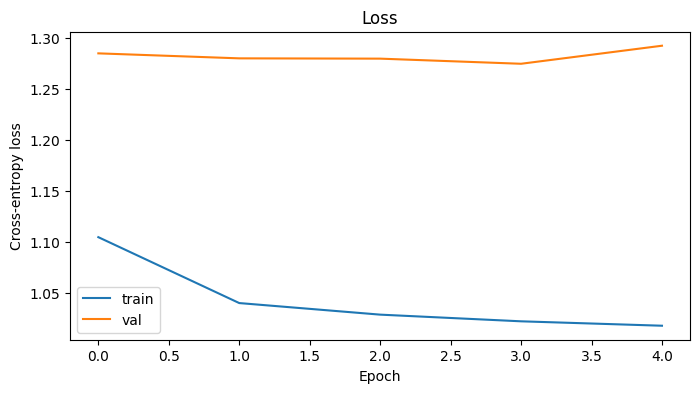

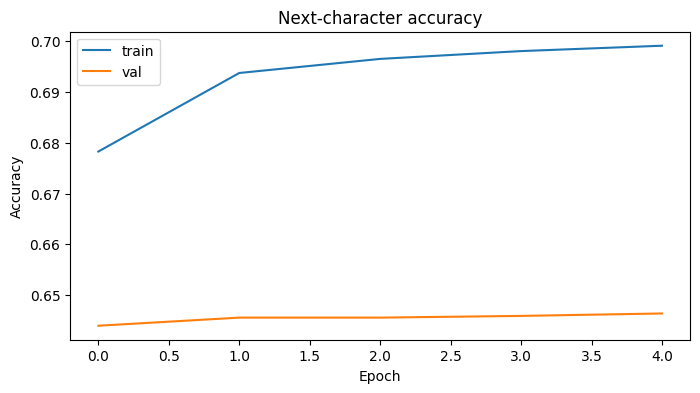

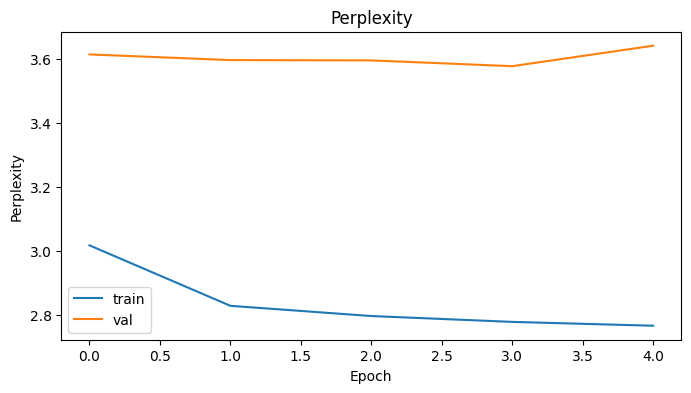

yeah 'jour 🤤🤤

and there was what I can get some bussy anymore

like image pull down to ruin

are you calling my add call olive?

I have to be peace then

Rip

Just free in the call

Oh I see

Too lazy from a chat part

Yeah true

True

How is it, i felundent cars is done, with the Packages in the couch of their favorite. France)

https://cdn.

lol cheese :(

Fwe is overally so we were actually a really start of my cousin liother that I got an except when I got home too

That would be a year with my small

lol

like a really big burger'

what the really were the game really got a little bit late

Fr

So I could block my tongers and last night boys

The lunch is just for a time though

just finishe


In [36]:
# plot train and validation accuracy of your model during training
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_accs, label="train")
plt.plot(val_accs, label="val")
plt.title("Next-character accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(train_ppls, label="train")
plt.plot(val_ppls, label="val")
plt.title("Perplexity")
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.legend()
plt.show()

# And try to generate some text
@torch.no_grad()
def generate_text(model, start_text="lol ", max_new_chars=300, temperature=0.8):
    model.eval()

    input_ids = torch.tensor([encode(start_text)], dtype=torch.long, device=device)
    hidden = None

    logits, hidden = model(input_ids)
    generated = list(start_text)

    current = input_ids[:, -1:]

    for _ in range(max_new_chars):
        logits, hidden = model(current, hidden)
        next_logits = logits[:, -1, :] / temperature
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)

        next_char = itos[next_id.item()]
        if next_char in ["<PAD>", "<UNK>"]:
            next_char = " "

        generated.append(next_char)
        current = next_id

        text = "".join(generated).replace("<EOS>", "")
        text = re.sub(r"<(?:E(?:O(?:S)?)?)?$", "", text)

    return text

print(generate_text(model, start_text="yeah ", max_new_chars=400, temperature=0.9))
print()
print(generate_text(model, start_text="lol ", max_new_chars=400, temperature=0.8))

Hint: look at earlier homework assignments / resuse code from those to help you here

# Part 4: Run Hyperparameter Experiments


[1/12] Trying: {'embed_dim': 64, 'hidden_dim': 128, 'num_layers': 1, 'lr': 0.001}
Best val loss: 1.4267 | best val acc: 0.6117 | best val ppl: 4.16

[2/12] Trying: {'embed_dim': 64, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.001}
Best val loss: 1.3446 | best val acc: 0.6285 | best val ppl: 3.84

[3/12] Trying: {'embed_dim': 64, 'hidden_dim': 256, 'num_layers': 1, 'lr': 0.001}
Best val loss: 1.3577 | best val acc: 0.6327 | best val ppl: 3.89

[4/12] Trying: {'embed_dim': 64, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
Best val loss: 1.2837 | best val acc: 0.6444 | best val ppl: 3.61

[5/12] Trying: {'embed_dim': 128, 'hidden_dim': 128, 'num_layers': 1, 'lr': 0.001}
Best val loss: 1.4038 | best val acc: 0.6146 | best val ppl: 4.07

[6/12] Trying: {'embed_dim': 128, 'hidden_dim': 128, 'num_layers': 2, 'lr': 0.001}
Best val loss: 1.3245 | best val acc: 0.6273 | best val ppl: 3.76

[7/12] Trying: {'embed_dim': 128, 'hidden_dim': 256, 'num_layers': 1, 'lr': 0.001}
Best val loss: 1.360

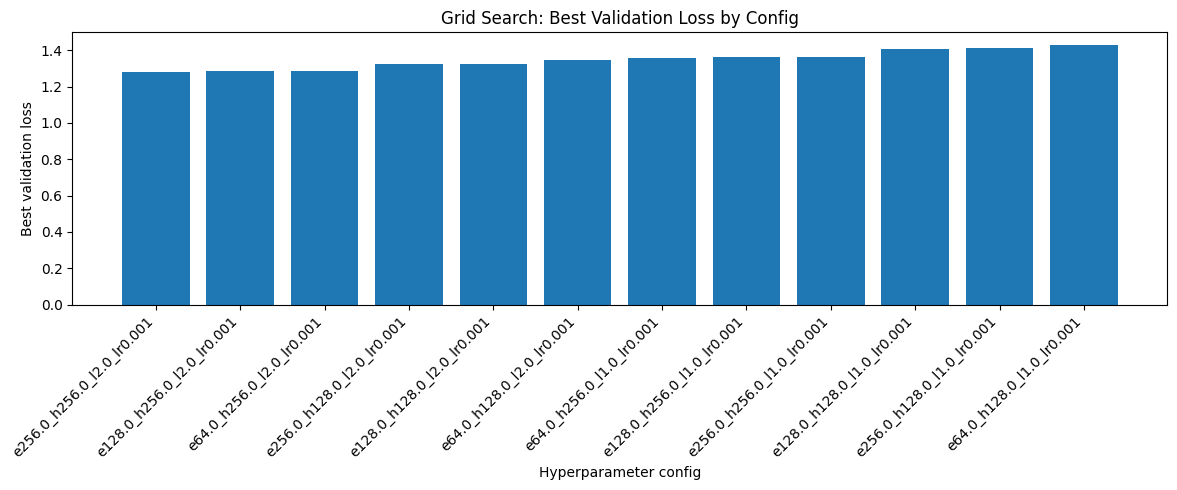

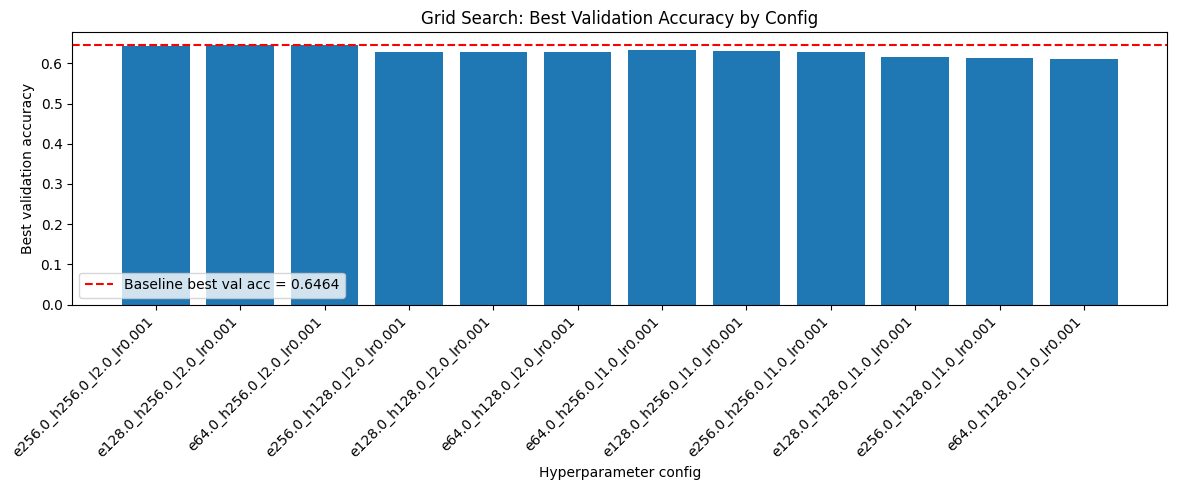

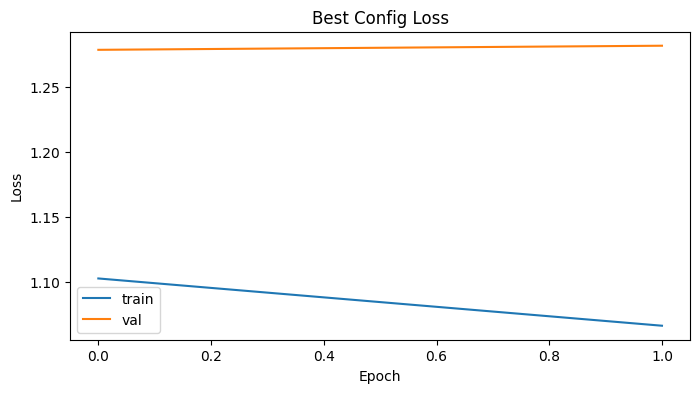

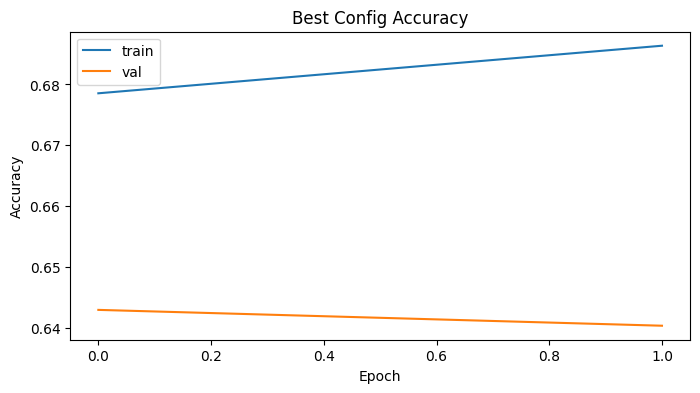

Saved model bundle to data\processed\discordModel.pt


In [13]:
# perform hyperparameter grid searches and plot accuracies
def train_model(embed_dim, hidden_dim, num_layers, lr, num_epochs=2):
    model = MessageGRU(
        vocab_size=VOCAB_SIZE,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=0.2,
    ).to(device)

    opt = optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_ppl": [],
        "val_ppl": [],
    }

    for epoch in range(num_epochs):
        train_loss, train_acc, train_ppl = run_epoch(model, train_loader, opt)
        val_loss, val_acc, val_ppl = run_epoch(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_ppl"].append(train_ppl)
        history["val_ppl"].append(val_ppl)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, best_val_loss, history

param_grid = {
    "embed_dim": [64, 128, 256],
    "hidden_dim": [128, 256],
    "num_layers": [1, 2],
    "lr": [0.001],
}

search_space = [
    dict(zip(param_grid.keys(), values))
    for values in product(*param_grid.values())
]

results = []
best_model = None
best_config = None
best_history = None
best_val_loss = float("inf")

for i, config in enumerate(search_space, 1):
    print(f"\n[{i}/{len(search_space)}] Trying: {config}")

    model_candidate, val_loss, history = train_model(**config, num_epochs=2)
    best_val_acc = max(history["val_acc"])
    best_val_ppl = min(history["val_ppl"])

    results.append({
        **config,
        "best_val_loss": val_loss,
        "best_val_acc": best_val_acc,
        "best_val_ppl": best_val_ppl,
    })

    print(
        f"Best val loss: {val_loss:.4f} | "
        f"best val acc: {best_val_acc:.4f} | "
        f"best val ppl: {best_val_ppl:.2f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model_candidate
        best_config = config
        best_history = history
    else:
        del model_candidate
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

results_df = pd.DataFrame(results).sort_values("best_val_loss").reset_index(drop=True)
results_df

results_df["label"] = results_df.apply(
    lambda row: f"e{row.embed_dim}_h{row.hidden_dim}_l{row.num_layers}_lr{row.lr}",
    axis=1
)

print("Best config:", best_config)

plt.figure(figsize=(12, 5))
plt.bar(results_df["label"], results_df["best_val_loss"])
plt.xticks(rotation=45, ha="right")
plt.title("Grid Search: Best Validation Loss by Config")
plt.xlabel("Hyperparameter config")
plt.ylabel("Best validation loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["label"], results_df["best_val_acc"])
plt.axhline(
    baseline_best_val_acc,
    color="red",
    linestyle="--",
    label=f"Baseline best val acc = {baseline_best_val_acc:.4f}"
)
plt.xticks(rotation=45, ha="right")
plt.title("Grid Search: Best Validation Accuracy by Config")
plt.xlabel("Hyperparameter config")
plt.ylabel("Best validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best_history["train_loss"], label="train")
plt.plot(best_history["val_loss"], label="val")
plt.title("Best Config Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(best_history["train_acc"], label="train")
plt.plot(best_history["val_acc"], label="val")
plt.title("Best Config Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# I also trained the best configuration for longer, and save it for later, since I want to use it for a bot for my friend groups discord server
final_model, final_val_loss, final_history = train_model(
    embed_dim=best_config["embed_dim"],
    hidden_dim=best_config["hidden_dim"],
    num_layers=best_config["num_layers"],
    lr=best_config["lr"],
    num_epochs=10
)

save_path = "discordModel.pt"

torch.save({
    "model_state_dict": final_model.state_dict(),
    "vocab_size": VOCAB_SIZE,
    "stoi": stoi,
    "itos": itos,
    "pad_idx": PAD_I,
    "unk_idx": UNK_I,
    "seq_len": seq_len,
}, save_path)

print("Saved model bundle to", save_path)

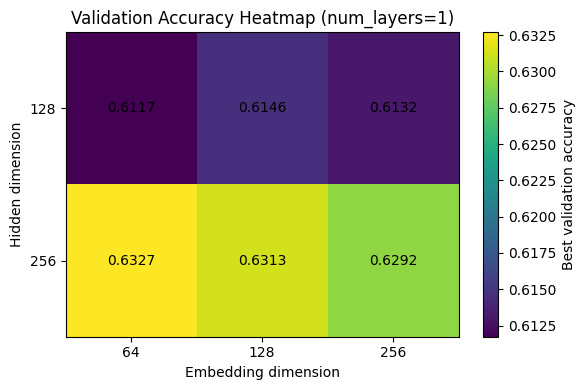

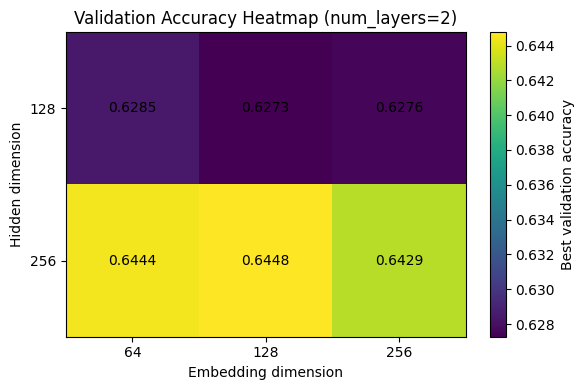

In [23]:
# Also here's a 'heatmap' since I forgot to add one in the cell above before running it, and it took like 10 hours to run
layer_values = sorted(results_df["num_layers"].unique())

for layer in layer_values:
    subset = results_df[results_df["num_layers"] == layer].copy()

    heatmap_data = subset.pivot(
        index="hidden_dim",
        columns="embed_dim",
        values="best_val_acc"
    )

    plt.figure(figsize=(6, 4))
    plt.imshow(heatmap_data, aspect="auto")
    plt.colorbar(label="Best validation accuracy")

    plt.xticks(range(len(heatmap_data.columns)), heatmap_data.columns)
    plt.yticks(range(len(heatmap_data.index)), heatmap_data.index)

    plt.xlabel("Embedding dimension")
    plt.ylabel("Hidden dimension")
    plt.title(f"Validation Accuracy Heatmap (num_layers={layer})")

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            plt.text(j, i, f"{value:.4f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [51]:
# perform other experiments and plot accuracies
# here I justed tested the outputs of different temperatures and prompts
temps = [0.5, 0.8, 1.0, 1.2]
prompts = ["yesterday ", "lmao ", "i hate "]

for prompt in prompts:
    print("=" * 60)
    print("PROMPT:", repr(prompt))
    for temp in temps:
        print(f"\nTemperature = {temp}")
        print(generate_text(final_model, start_text=prompt, max_new_chars=250, temperature=temp))

PROMPT: 'yesterday '

Temperature = 0.5
yesterday out of the groundarine right and it doesn't see that as a piece of my pants or something the only like that because it's like 6 star account to get a couple weeks though

I already come over :3

yeah

I would have to go to over a subme

Temperature = 0.8
yesterday done

It wasn't too potonate like that

wanna play his car before that about that

?

Yeah I checked those crashed now

Now i don't remember what their

gabe was gonna get your personiest

https://tenor.com/view/wit

Temperature = 1.0
yesterday as whiterup ln days

they're 7 ready

ye

lmao got 6 days pretty taco but english

lol

So that are stuff unrubboy

Same

My memes your source with the tudger

yoooooo

lmao

Rn

This is he won't

Temperature = 1.2
yesterday chi's ehembe I

Ulin

GG

how more event if I'm very magic

as love stuff for the turned animal rope minority

🥚

reidbock #take alcksw

I thought it will bought about a physical boker

but treat, run

wal
PROMPT: '

In [15]:
# calculate the final test accuracy
test_loss, test_acc, test_ppl = run_epoch(final_model, test_loader)

print("Best config:", best_config)
print(f"Final test loss={test_loss:.4f}")
print(f"Final test accuracy={test_acc:.4f}")
print(f"Final test perplexity={test_ppl:.2f}")

Best config: {'embed_dim': 256, 'hidden_dim': 256, 'num_layers': 2, 'lr': 0.001}
Final test loss=2.1914
Final test accuracy=0.5915
Final test perplexity=8.95


For my grid search experimentation, I mostly wanted to see how architectural changes would affect the model, so I tried out different dimensions and layer amounts, and kept the learning rate the same in each of them, since this value seems to have done good in other cases during the course. And then I performed some smaller experiments with just changing the tempurature and prompts of the best model, this obviously isn't hcanging accuracy or anything, but is more of a qualitative experiement to see which values are best. The text it outputs isn't incredible, however it is generating actual words, and using emoticons and phrases that work well, and makes me and my friend group laugh with its output, which is good.